# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project Notebook: Image Classification using Multi Layer Perceptron

## Learning Objectives

At the end of the experiment, you will be able to :

* load and extract features of images

* implement the Multi-Layer perceptron to classify images

* implement simple neural network from keras

## Introduction

Traffic sign recognition is a challenging, real-world problem relevant for AI based transportation systems. Traffic signs show a wide range of variations between classes in terms of color, shape, and the presence of pictograms or text. However, there exist subsets of
classes (e.g., speed limit signs) that are very similar to each other. Further, the classifier
has to be robust against large variations in visual appearances due to changes in illumination, partial
occlusions, rotations, weather conditions etc. Using a comprehensive traffic sign detection dataset, here we will perform classification of traffic signs, train and evaluate the different models and compare to the performance of MLPs.

![img](https://paperswithcode.com/media/datasets/GTSRB-0000000633-9ce3c5f6_Dki5Rsf.jpg)

## Dataset

The data for this mini-project is from the German Traffic Sign Detection Benchmark [GTSDB](https://benchmark.ini.rub.de/gtsdb_dataset.html). This archive contains the training set used during the IJCNN 2013 competition. 

The German Traffic Sign Detection Benchmark is a single-image detection assessment for researchers with interest in the field of computer vision, pattern recognition and image-based driver assistance. It is introduced on the IEEE International Joint Conference on Neural Networks 2013. 

It features ...

* The main archive FullIJCNN2013.zip includes the images (1360 x 800 pixels) in PPM format, the image sections containing only the traffic signs
* A file in CSV format with the ground truth
* A ReadMe.txt with more details.

Note that we will be using the images inside the image sections subfolders, containing only the traffic signs.

## Problem Statement

To build and improve upon a machine learning model for the classification of images and achieve a high accuracy final model.

## Grading = 10 Points

In [ ]:
#@title Download the data
!wget -qq https://sid.erda.dk/public/archives/ff17dc924eba88d5d01a807357d6614c/FullIJCNN2013.zip
!unzip -qq FullIJCNN2013.zip

### Import Required packages

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from skimage.io import imread, imshow
from sklearn import preprocessing
import os, glob
from PIL import Image
from sklearn.model_selection import GridSearchCV
# Keras
import tensorflow as tf 
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### Data Loading and Feature Extraction (2 points)

#### Get the features and labels of data

* Extract the features of the images within image sections only (do not use images located outside these folders)
* Extract labels of the images
* Resize the images to (30, 30) and convert to numpy 1-D array

   Hint: [Link](https://machinelearningmastery.com/how-to-load-and-manipulate-images-for-deep-learning-in-python-with-pil-pillow/)

In [ ]:
# YOUR CODE HERE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
# Read Image, Resize and convert to 1D array
def get_image_data (img_file:Path, img_resize:tuple = (30,30)) -> tuple:
    ''' resize image and get image data as 1D-array '''

    image = Image.open(img_file)
    image = image.resize(img_resize)  # resize to 30x30

    # convert to np_array (for RGB color image = 30x30x3)
    img_array = np.asarray(image)

    return img_array.ravel()
    

In [ ]:
# Extract X, y
X, y = np.empty((0,2700), float), np.empty((0), int)
filename = list()
root = '/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013'
for dir in os.listdir(root):
    dir_path = os.path.join(root,dir)
    if os.path.isdir(dir_path):
        for file in os.listdir(dir_path):
            file_url = os.path.join(dir_path, file)
            print(file_url)
            _1d_array = get_image_data(file_url)
            X = np.vstack([X,_1d_array])
            y = np.hstack([y,np.array([int(dir)])])
            filename.append(file_url)            

/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013/42/00000.ppm
/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013/42/00001.ppm
/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013/42/00003.ppm
/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013/42/00002.ppm
/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013/42/00006.ppm
/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013/42/00005.ppm
/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013/42/00004.ppm
/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01, 2022 - Sunday/Data Files/FullIJCNN2013/42/00007.ppm
/content/drive/MyDrive/Copy-CDS-B3/Module 4/MiniProjects/May 01,

In [ ]:
X.shape, y.shape

((1213, 2700), (1213,))

In [ ]:
# Normalize X. Same as X/255
X_s = preprocessing.normalize(X, norm='max', axis=0)
X_train, X_test, y_train, y_test = train_test_split(X_s, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = MLPClassifier(activation='relu', 
                      max_iter=1000, 
                      hidden_layer_sizes=(42,28)
                      )

In [ ]:
model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(42, 28), max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.8559670781893004

In [ ]:
parameter_space = {
    'hidden_layer_sizes': [(28,28), (50,50), (50,50,50), (42, 28),(42, 28,7), (42, 28, 14, 7), (50,50,25),(25,25)],
    'activation': ['tanh', 'relu', 'logistic'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.001,0.01,0.05],
    'learning_rate': ['constant','adaptive'],
    'max_iter': [1000,1200,1400,1600,1800,2000 ],
    'alpha': [1e-4,2e-4,1e-5]
}


In [ ]:
mlp = MLPClassifier()
clf_r = RandomizedSearchCV(mlp, parameter_space, n_iter = 10, cv=2, n_jobs=6)
clf_r.fit(X_train, y_train)


RandomizedSearchCV(cv=2, estimator=MLPClassifier(), n_jobs=6,
                   param_distributions={'activation': ['tanh', 'relu',
                                                       'logistic'],
                                        'alpha': [0.0001, 0.0002, 1e-05],
                                        'hidden_layer_sizes': [(28, 28),
                                                               (50, 50),
                                                               (50, 50, 50),
                                                               (42, 28),
                                                               (42, 28, 7),
                                                               (42, 28, 14, 7),
                                                               (50, 50, 25),
                                                               (25, 25)],
                                        'learning_rate': ['constant',
                                                    

In [ ]:
model = clf_r.best_estimator_

In [ ]:
clf_r.best_params_

{'activation': 'tanh',
 'alpha': 0.0002,
 'hidden_layer_sizes': (28, 28),
 'learning_rate': 'adaptive',
 'max_iter': 1000,
 'solver': 'adam'}

In [ ]:
accuracy_score(y_test, model.predict(X_test))

0.8888888888888888

In [ ]:
def compute_accuracy(model):

    model.fit(X_train, y_train)
    print(f'{type(model).__name__}: {accuracy_score(y_test, model.predict(X_test))}')

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier


classifiers = [
    SVC(),
    RandomForestClassifier(max_depth=2, random_state=0),
    AdaBoostClassifier(n_estimators=10, random_state=0),  # based estimator : Decision Tree Classifier
    SGDClassifier(max_iter=1000, tol=1e-3)
]

for cls in classifiers:
    compute_accuracy(cls)

SVC: 0.5185185185185185
RandomForestClassifier: 0.3004115226337449
AdaBoostClassifier: 0.13991769547325103
SGDClassifier: 0.757201646090535


### Data Exploration and Preprocessing ( 2 points)

#### Plot the sample image of each class

Hint: plt.subplot

Label:  0


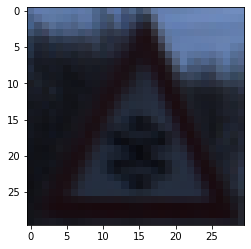

Label:  1


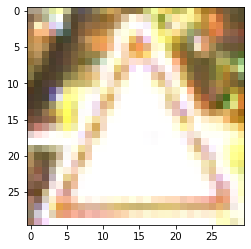

Label:  2


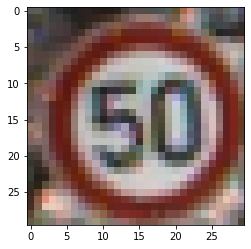

Label:  3


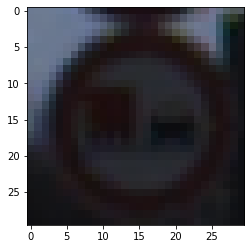

Label:  4


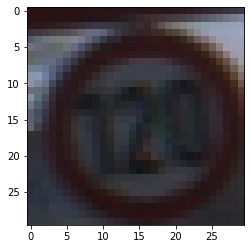

Label:  5


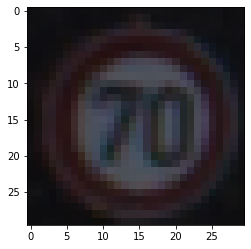

Label:  6


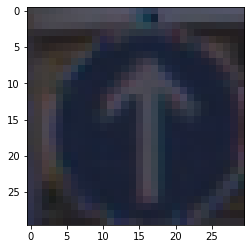

Label:  7


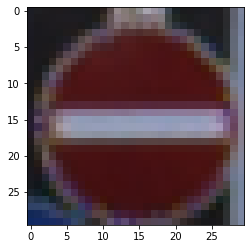

Label:  8


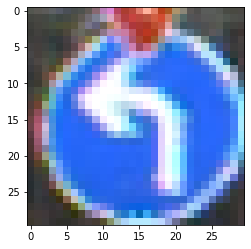

Label:  9


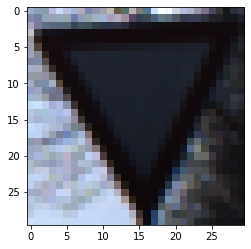

Label:  10


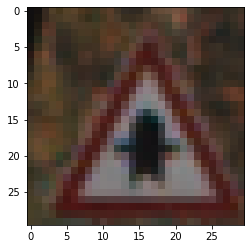

Label:  11


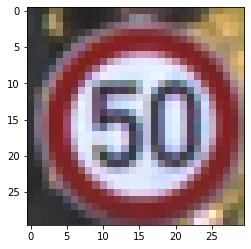

Label:  12


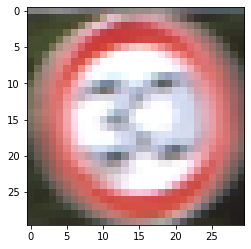

Label:  13


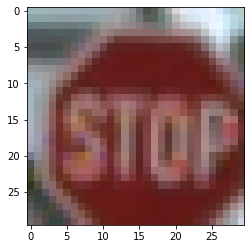

Label:  14


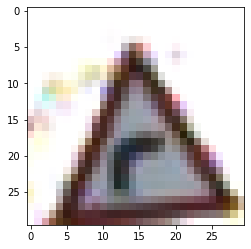

Label:  15


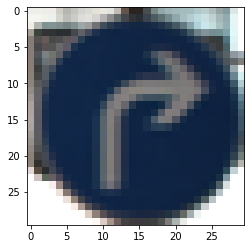

Label:  16


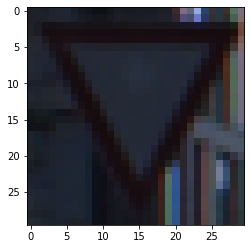

Label:  17


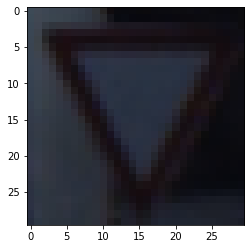

Label:  18


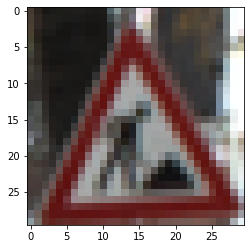

Label:  19


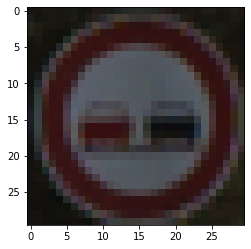

Label:  20


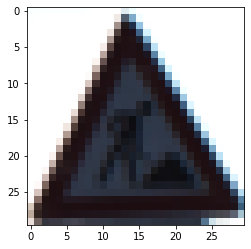

Label:  21


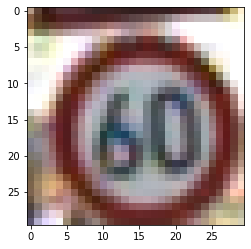

Label:  22


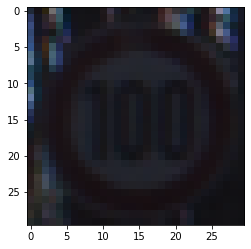

Label:  23


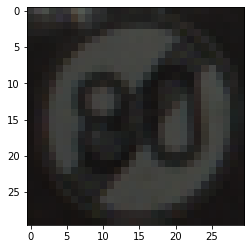

Label:  24


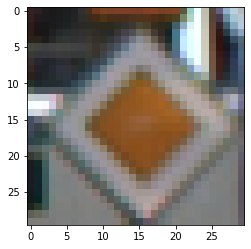

Label:  25


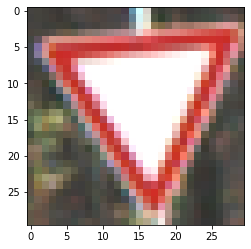

Label:  26


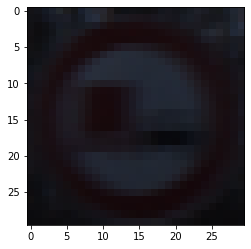

Label:  27


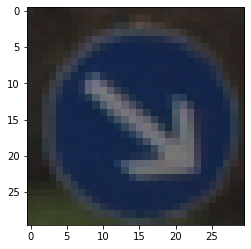

Label:  28


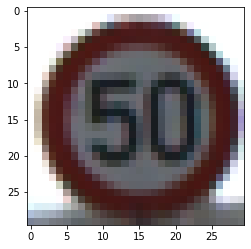

Label:  29


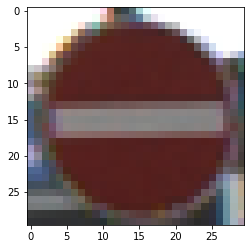

Label:  30


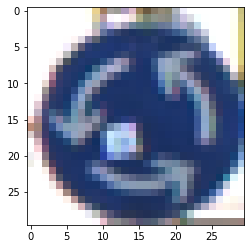

Label:  31


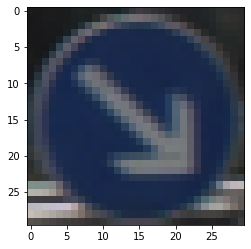

Label:  32


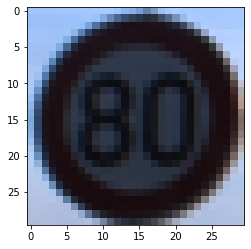

Label:  33


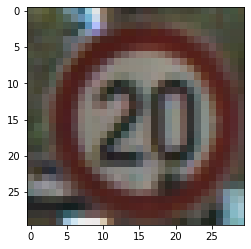

Label:  34


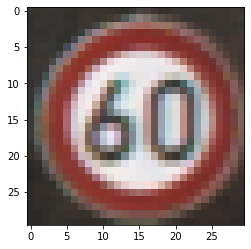

Label:  35


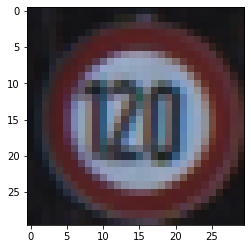

Label:  36


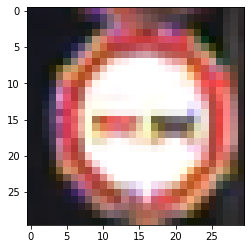

Label:  37


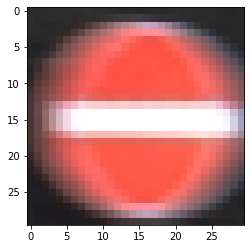

Label:  38


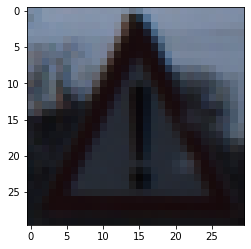

Label:  39


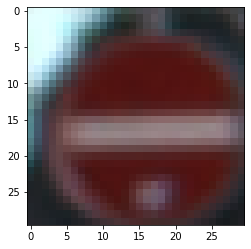

Label:  40


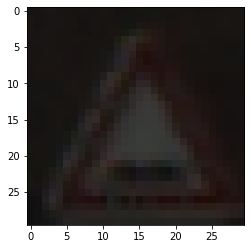

Label:  41


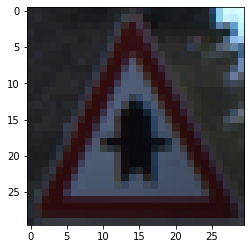

Label:  42


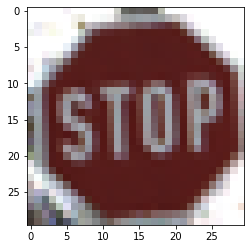

In [ ]:
# YOUR CODE HERE
for c in np.unique(y):
  print("Label: ", c)
  plt.imshow(X_train_full[c], cmap='Greys')
  plt.show()

#### Plot the distribution of Classes

In [ ]:
# YOUR CODE HERE

#### Normalize the features

For most image data, the pixel values are integers with values between 0 and 255.

Neural networks process inputs using small weight values, and inputs with large integer values can disrupt or slow down the learning process. As such it is good practice to normalize the pixel values.

Hint: sklearn.preprocessing.normalize

In [ ]:
# YOUR CODE HERE

### Train the MLP classifier on features (1 point)

* Split the data into train and test

* Train the MLP classifier with different parameters

* Get the accuracy score and performance metrics

In [ ]:
# YOUR CODE HERE

### Tune the hyper-parameters (2 points)

* Use the GridSearchCV or RandomizedSearchCV and select best parameters

  Hint: [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

  (or)
* Manually change and find the best parameters

To know about all the parameters, click [here](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

In [ ]:
# YOUR CODE HERE

#### Try the different algorithms and compare the results with MLP classifier

In [ ]:
# YOUR CODE HERE

### Implement simple Neural Networks using keras (3 points)

* Define the keras model and initialize the layers
  - Ensure the input layer has the right number of input features. This can be specified when creating the first layer with the input_dim argument.
* Compile the model
  - Specify the loss function (to evaluate a set of weights), the optimizer (is used to search through different weights for the network) and any optional metrics to collect and report during training.
* Fit and Evaluate the model
  - Fit the data by specifying epochs and evaluate the model

In [ ]:
print(tf.__version__)

2.8.0


In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X_s, y, test_size=0.2, random_state=42,stratify = y)

In [ ]:
pd.Series(y_test).value_counts()

38    18
12    17
13    17
10    16
1     16
2     16
4     14
5     11
8     11
11     8
18     8
7      8
9      8
25     6
17     6
14     6
3      6
23     4
35     4
26     4
6      4
30     3
22     3
15     3
33     3
28     3
34     2
40     2
20     2
36     2
42     2
16     2
32     2
41     1
0      1
39     1
21     1
24     1
29     1
dtype: int64

In [ ]:
# Step 1 - Build the architecture
# YOUR CODE HERE
# Validation set and scaling
idx = np.random.permutation(len(y_train_full))
X_train_full = X_train_full[idx]
y_train_full = y_train_full[idx]
X_valid = X_train_full[:200] 
X_train = X_train_full[200:] 
y_valid = y_train_full[:200]
y_train = y_train_full[200:]

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f9c1819bd10>]],
      dtype=object)

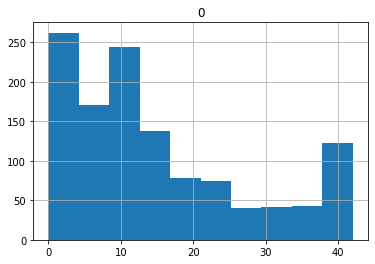

In [ ]:
pd.DataFrame(y).hist()

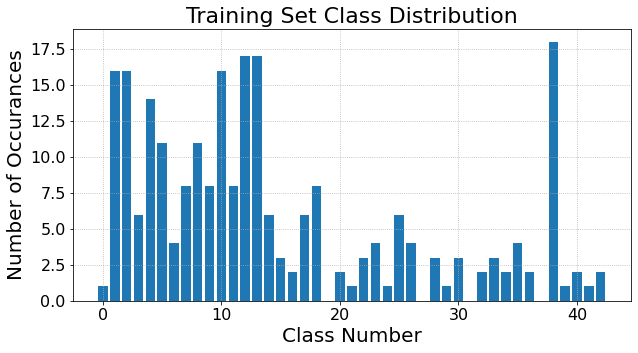

In [ ]:
plt.figure(0, figsize = (10,5))
unique_train, counts_train = np.unique(y_test, return_counts = True)
plt.bar(unique_train, counts_train)
plt.title('Training Set Class Distribution', fontsize=22)
plt.xlabel('Class Number', fontsize=20)
plt.ylabel('Number of Occurances', fontsize=20)
plt.tick_params(labelsize=16)
plt.grid(linestyle=':')

In [ ]:
# Step 2 - Compile the model
# YOUR CODE HERE
from tensorflow.keras.layers import Flatten, Dense
nn_model = Sequential([
                    Flatten(input_shape=[30, 30, 3]),
                    Dense(50, activation="tanh"),
                    Dense(50,activation="tanh"),
                    Dense(43, activation="softmax")
                    ])

In [ ]:
# Step 3 - Fit and Evaluate the model
# YOUR CODE HERE
nn_model.compile(loss = 'sparse_categorical_crossentropy', optimizer = "adam", metrics = ['accuracy'])
nn_model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_6 (Flatten)         (None, 2700)              0         
                                                                 
 dense_21 (Dense)            (None, 50)                135050    
                                                                 
 dense_22 (Dense)            (None, 50)                2550      
                                                                 
 dense_23 (Dense)            (None, 43)                2193      
                                                                 
Total params: 139,793
Trainable params: 139,793
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = nn_model.fit(X_train, y_train, epochs = 100, validation_data = (X_valid,y_valid))

Epoch 1/100
25/25 [==============================] - 1s 9ms/step - loss: 3.4370 - accuracy: 0.1455 - val_loss: 3.3465 - val_accuracy: 0.1100
Epoch 2/100
25/25 [==============================] - 0s 4ms/step - loss: 3.1404 - accuracy: 0.1935 - val_loss: 3.0549 - val_accuracy: 0.2450
Epoch 3/100
25/25 [==============================] - 0s 5ms/step - loss: 2.7976 - accuracy: 0.3104 - val_loss: 2.7352 - val_accuracy: 0.3300
Epoch 4/100
25/25 [==============================] - 0s 3ms/step - loss: 2.5136 - accuracy: 0.4026 - val_loss: 2.7026 - val_accuracy: 0.2850
Epoch 5/100
25/25 [==============================] - 0s 4ms/step - loss: 2.3244 - accuracy: 0.4312 - val_loss: 2.3105 - val_accuracy: 0.4150
Epoch 6/100
25/25 [==============================] - 0s 4ms/step - loss: 2.0927 - accuracy: 0.4429 - val_loss: 2.1364 - val_accuracy: 0.4500
Epoch 7/100
25/25 [==============================] - 0s 4ms/step - loss: 1.9028 - accuracy: 0.5312 - val_loss: 2.0021 - val_accuracy: 0.4600
Epoch 8/100
2

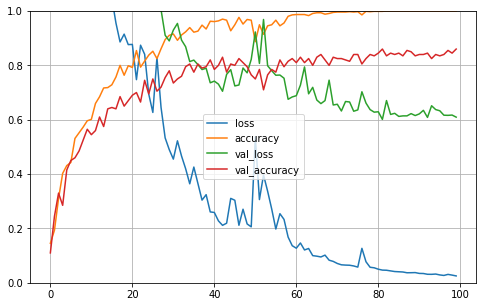

In [ ]:
# YOUR CODE HERE
df = pd.DataFrame(history.history)
df.plot(figsize=(8, 5))
plt.grid(True)
# set the vertical range to [0-1]
plt.gca().set_ylim(0, 1) 
plt.show()

In [ ]:
model.evaluate(X_test,y_test)

8/8 [==============================] - 0s 2ms/step - loss: 0.6149 - accuracy: 0.8807


[0.6149242520332336, 0.8806584477424622]

In [ ]:
X_new = X_test[:3]
y_pred = np.argmax(model.predict(X_new), axis=-1)
# YOUR CODE HERE to show 'y_pred'
print("predicted labels:",y_pred)

predicted labels: [10 22  5]


In [ ]:
X_new = X_test[:3]
y_pred = np.argmax(model.predict(X_new), axis=-1)
# YOUR CODE HERE to show 'y_pred'
print("predicted labels:",y_pred)

predicted labels: [10 22  5]


actual labels: [10 22  5]


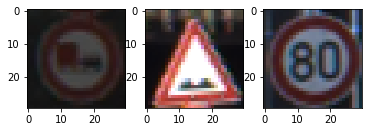

In [ ]:
# Actual labels
y_new = y_test[:3]
# YOUR CODE HERE to show 'y_new'
print("actual labels:", y_new)
fig, ax = plt.subplots(1,3)
for axi, i in zip(ax.ravel(), np.arange(len(X_new))):
    axi.imshow(X_new[i], cmap='Greys')

In [ ]:
y_hat = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
classification_report(np.argmax(y_hat,axis=1),y_test).split("\n")

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1

['              precision    recall  f1-score   support',
 '',
 '           0       0.00      0.00      0.00         0',
 '           1       1.00      0.89      0.94        18',
 '           2       0.94      0.94      0.94        16',
 '           3       1.00      1.00      1.00         6',
 '           4       0.93      0.87      0.90        15',
 '           5       0.82      0.90      0.86        10',
 '           6       1.00      0.80      0.89         5',
 '           7       0.75      0.86      0.80         7',
 '           8       0.91      0.83      0.87        12',
 '           9       1.00      1.00      1.00         8',
 '          10       1.00      0.94      0.97        17',
 '          11       1.00      0.89      0.94         9',
 '          12       0.94      1.00      0.97        16',
 '          13       0.88      0.94      0.91        16',
 '          14       1.00      1.00      1.00         6',
 '          15       0.67      1.00      0.80         2',
 '       

In [ ]:
y_pred

array([10, 22,  5])

#### Try the same parameters used for MLP Classifier and build the keras model

In [ ]:
# YOUR CODE HERE

#### Experiment using Dropout, Regularization and Batch Normalization

In [ ]:
# YOUR CODE HERE
# YOUR CODE HERE
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, InputLayer, Conv1D, ReLU, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
eval_model = Sequential([
                    Flatten(input_shape=[30, 30,3]),
                    BatchNormalization(),
                    Dense(50, activation="tanh"),
                    BatchNormalization(),
                    Dropout(0.2),
                    Dense(50,activation="tanh"),
                    Dropout(0.2),
                    Dense(43, activation="softmax")
                    ])

In [ ]:
eval_model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
eval_model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_8 (Flatten)         (None, 2700)              0         
                                                                 
 batch_normalization_2 (Batc  (None, 2700)             10800     
 hNormalization)                                                 
                                                                 
 dense_27 (Dense)            (None, 50)                135050    
                                                                 
 batch_normalization_3 (Batc  (None, 50)               200       
 hNormalization)                                                 
                                                                 
 dropout_2 (Dropout)         (None, 50)                0         
                                                                 
 dense_28 (Dense)            (None, 50)               

In [ ]:
history1 = eval_model.fit(X_train, y_train, epochs = 100, validation_data = (X_valid,y_valid))

Epoch 1/100
25/25 [==============================] - 1s 12ms/step - loss: 3.6058 - accuracy: 0.1052 - val_loss: 3.5095 - val_accuracy: 0.1200
Epoch 2/100
25/25 [==============================] - 0s 5ms/step - loss: 3.0650 - accuracy: 0.2779 - val_loss: 3.0477 - val_accuracy: 0.3100
Epoch 3/100
25/25 [==============================] - 0s 5ms/step - loss: 2.7253 - accuracy: 0.3623 - val_loss: 2.7711 - val_accuracy: 0.3400
Epoch 4/100
25/25 [==============================] - 0s 6ms/step - loss: 2.4973 - accuracy: 0.4065 - val_loss: 2.5573 - val_accuracy: 0.4200
Epoch 5/100
25/25 [==============================] - 0s 5ms/step - loss: 2.2443 - accuracy: 0.4766 - val_loss: 2.2975 - val_accuracy: 0.4150
Epoch 6/100
25/25 [==============================] - 0s 6ms/step - loss: 2.0922 - accuracy: 0.4870 - val_loss: 2.0503 - val_accuracy: 0.5200
Epoch 7/100
25/25 [==============================] - 0s 6ms/step - loss: 1.8736 - accuracy: 0.5429 - val_loss: 1.8117 - val_accuracy: 0.5300
Epoch 8/100


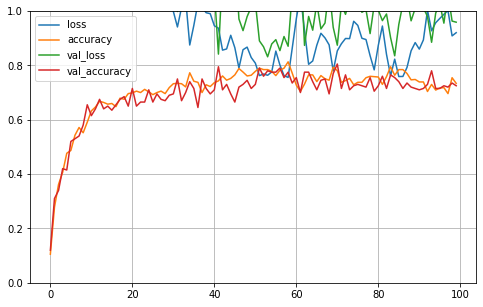

In [ ]:
# YOUR CODE HERE
df = pd.DataFrame(history1.history)
df.plot(figsize=(8, 5))
plt.grid(True)
# set the vertical range to [0-1]
plt.gca().set_ylim(0, 1) 
plt.show()

In [ ]:
eval_model.evaluate(X_test,y_test)

8/8 [==============================] - 0s 2ms/step - loss: 0.7888 - accuracy: 0.7901


[0.7888167500495911, 0.790123462677002]

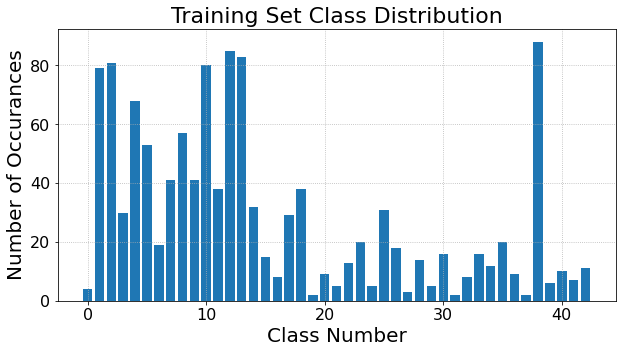

### Report Analysis

* According to the confusion matrix, for which sign were the maximum misclassifications observed? Comment on the misclassification, owing to similar appearing traffic signs, if any. 
* Comment on the performance of the MLP Classifier
* Discuss the optimal number of layers, activation functions, optimizers etc. that yielded the best accuracy
* Report on training time vs convergence

Reference: J. Stallkamp, M. Schlipsing, J. Salmen, and C. Igel. The German Traffic Sign Recognition Benchmark: A multi-class classification competition. In Proceedings of the IEEE International Joint Conference on Neural Networks, pages 1453–1460. 2011.